In [1]:
import sys
import subprocess
import importlib

packages = ['tensorflow','numpy','matplotlib','torch']
for p in packages:
    try:
        importlib.import_module(p)
    except Exception:
        print(f"Installing {p}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', p])

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 6, 8, 10], dtype=float)

In [3]:
tf_model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

c:\Users\Naveen Kumar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 4: Compile the Model

In [4]:
tf_model.compile(
    optimizer='sgd',
    loss='mean_squared_error',
    metrics=['mae']
)

In [5]:
history_reg = tf_model.fit(x, y, epochs=200, verbose=0)

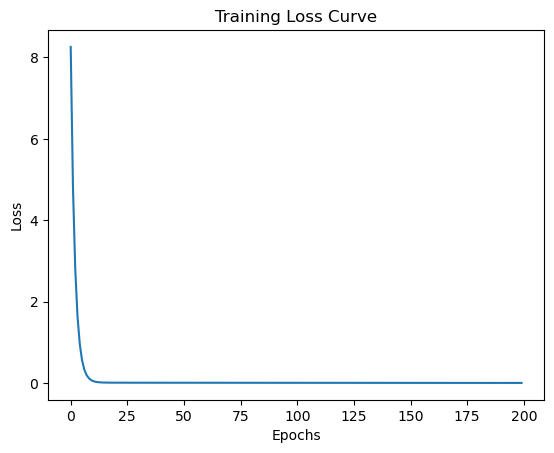

In [6]:
plt.plot(history_reg.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

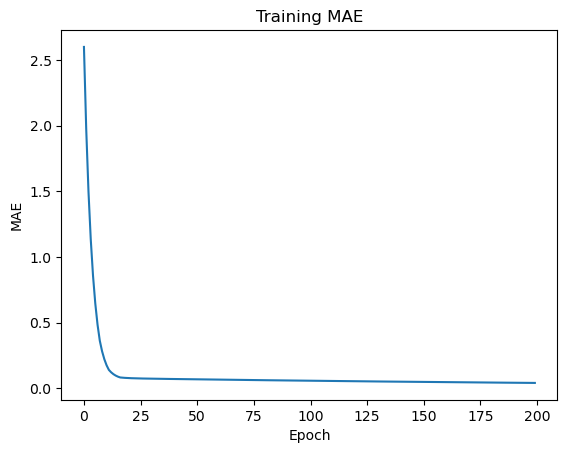

In [7]:
if 'mae' in history_reg.history:
    plt.plot(history_reg.history['mae'])
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Training MAE")
    plt.show()
else:
    print("No 'mae' metric in history_reg. Available metrics:", list(history_reg.history.keys()))


In [8]:
import numpy as np

print(tf_model.predict(np.array([[10]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[19.799612]]


In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [10]:
x = torch.tensor([[1.0],[2.0],[3.0],[4.0],[5.0]])
y = torch.tensor([[2.0],[4.0],[6.0],[8.0],[10.0]])

In [11]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1,1)

    def forward(self, x):
        return self.linear(x)

torch_model = SimpleModel()

In [12]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.01)

In [13]:
losses = []

for epoch in range(200):
    optimizer.zero_grad()
    output = torch_model(x)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

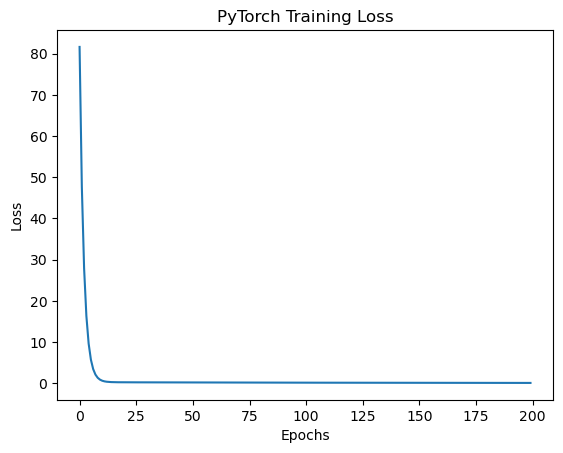

In [14]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("PyTorch Training Loss")
plt.show()

In [15]:
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.show()
else:
    print("No 'accuracy' metric in history. Available metrics:", list(history.history.keys()))


NameError: name 'history' is not defined

In [ ]:
print(torch_model(torch.tensor([[10.0]])))

tensor([[20.1225]], grad_fn=<AddmmBackward0>)


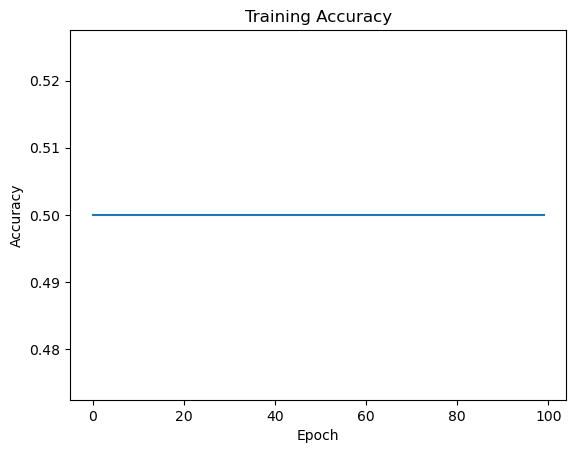

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Data (classification)
x = np.array([1,2,3,6,7,8], dtype=float)
y = np.array([0,0,0,1,1,1], dtype=int)

# Model
tf_clf = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=[1])
])

# Compile (IMPORTANT)
tf_clf.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history_clf = tf_clf.fit(
    x, y,
    epochs=100,
    verbose=0
)

# Plot Accuracy (use recorded metric if available, otherwise compute)
if 'accuracy' in history_clf.history:
    plt.plot(history_clf.history['accuracy'])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.show()
else:
    preds = (tf_clf.predict(x) > 0.5).astype(int).reshape(-1)
    acc = (preds == y.reshape(-1)).mean()
    print("Computed accuracy:", acc)
    plt.bar([0,1], [ (y==0).mean(), (y==1).mean() ])
    plt.title("Class distribution (for reference)")
    plt.show()